# Exploratory Data Analysis - Lab Exercise 

## Lab Objective

Perform comprehensive exploratory data analysis on a retail sales dataset to understand customer purchasing behavior and identify key insights.

## Dataset Description

**Filename:** `retail_sales.csv`

**Columns:**
- transaction_id: Unique identifier for each transaction
- date: Transaction date
- customer_id: Unique customer identifier
- age: Customer age
- gender: Customer gender (Male/Female)
- product_category: Category of product purchased
- quantity: Number of items purchased
- price_per_unit: Price of single unit
- total_amount: Total transaction amount

## Required Libraries

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
```

In [1]:
import pandas as pd  # used for loading, cleaning, and analyzing tabular data
import numpy as np  # used for numerical operations and array-based calculations
import matplotlib.pyplot as plt  # used for creating basic plots and visualizations
import seaborn as sns  # used for creating statistical and visually appealing plots
from scipy import stats  # provides statistical tests and distributions

## Part 1: Data Loading and Initial Exploration (15 points)

### Task 1.1: Load and Display Data
Load the dataset and display:
- First 10 rows
- Basic dataset information using `.info()`
- Dataset shape (number of rows and columns)
- Column names and their data types


In [2]:
# Solution

from IPython.display import display   # importing this library to clearly display all the info

df = pd.read_csv("retail_sales.csv")  # loads the CSV file into df

# Display first 10 rows
display(df.head(10))  # displays the first 10 rows of the DataFrame

# Display basic dataset information using .info()
df.info()             # shows a concise summary of the DataFrame

# Display dataset shape (number of rows and columns)
print("Number of rows and columns in the dataframe : ")
print(df.shape)              # returns the number of rows and columns

# Display column names and their data types
df.dtypes             # shows the data type of each column in the DataFrame


,transaction_id,date,customer_id,age,gender,product_category,quantity,price_per_unit,total_amount
0,1,19-06-2024,1102,62,Female,Beauty,1,50.59,50.59
1,2,03-02-2024,1435,22,Female,Electronics,3,278.92,836.76
2,3,26-01-2024,1860,50,Male,Home & Kitchen,3,322.61,967.83
3,4,24-05-2024,1270,18,Male,Electronics,5,353.38,1766.90
4,5,17-03-2024,1106,35,Female,Home & Kitchen,4,189.76,759.04
5,6,21-06-2024,1071,49,Female,Home & Kitchen,1,284.01,284.01
6,7,27-06-2024,1700,64,Female,Groceries,5,228.09,1140.45
7,8,11-06-2024,1020,66,Female,Beauty,5,337.67,1688.35
8,9,19-05-2024,1614,28,Male,Sports,1,293.86,293.86
9,10,20-04-2024,1121,38,Female,Home & Kitchen,1,265.25,265.25


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    1000 non-null   int64  
 1   date              1000 non-null   object 
 2   customer_id       1000 non-null   int64  
 3   age               1000 non-null   int64  
 4   gender            1000 non-null   object 
 5   product_category  1000 non-null   object 
 6   quantity          1000 non-null   int64  
 7   price_per_unit    1000 non-null   float64
 8   total_amount      1000 non-null   float64
dtypes: float64(2), int64(4), object(3)
memory usage: 70.4+ KB
Number of rows and columns in the dataframe : 
(1000, 9)


transaction_id        int64
date                 object
customer_id           int64
age                   int64
gender               object
product_category     object
quantity              int64
price_per_unit      float64
total_amount        float64
dtype: object

### Task 1.2: Initial Observations
Write your observations about:
- How many transactions are in the dataset?
- What types of variables do you have (numerical vs categorical)?
- Which column might need data type conversion?

**My observations:**
- The dataset contains 1000 transactions (indicated by the number of rows)
- The dataset has a mix of numerical and categorical variables:
    • Numerical: transaction_id, customer_id, age, quantity, price_per_unit, total_amount
    • Categorical: gender, product_category
    • Date/time: date (currently stored as object)
- The 'date' column might need data type conversion to datetime for easier time-based analysis.

## Part 2: Data Cleaning (20 points)

### Task 2.1: Convert Data Types
Convert the `date` column to datetime format.

**Your code here**

In [3]:
# Solution

df['date'] = pd.to_datetime(df['date'], dayfirst=True)  # converts 'date' column to datetime format, specifying day comes first

df.dtypes  # verifying the conversion

transaction_id               int64
date                datetime64[ns]
customer_id                  int64
age                          int64
gender                      object
product_category            object
quantity                     int64
price_per_unit             float64
total_amount               float64
dtype: object

### Task 2.2: Identify Missing Values
- Check for missing values in all columns
- Calculate the percentage of missing values for each column
- Display your findings

In [4]:
# Solution

# Creating a table showing both the count and percentage of missing values for each column
missing_table = pd.DataFrame({
    "Missing Count": df.isnull().sum(),                         # counts missing values per column
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100   # calculates percentage of missing values per column
})

if missing_table["Missing Count"].sum() == 0:
    print("No missing values in the dataset")  # prints this message if there are no missing values

missing_table  # displays the missing values table 

No missing values in the dataset


,Missing Count,Missing Percentage
transaction_id,0,0.0
date,0,0.0
customer_id,0,0.0
age,0,0.0
gender,0,0.0
product_category,0,0.0
quantity,0,0.0
price_per_unit,0,0.0
total_amount,0,0.0


### Task 2.3: Handle Missing Values
Based on your findings:
- Fill missing values in the `age` column with an appropriate measure of central tendency
- Fill missing values in the `gender` column with an appropriate value
- Verify that all missing values have been handled


In [5]:
# Solution

# Fill missing values in 'age' column with median
df['age'] = df['age'].fillna(df['age'].median())  # replaces missing ages with median

# Fill missing values in 'gender' column with mode (most frequent value)
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])  # replaces missing genders with most frequent value

# Verify that all missing values have been handled
missing_table_after = pd.DataFrame({
    "Missing Count": df.isnull().sum(),                         # counts missing values per column
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100   # calculates percentage of missing values per column
})

# Showing that no missing values remain
if missing_table_after["Missing Count"].sum() == 0:
    print("All missing values have been handled")  # confirmation message

missing_table_after  # displays the updated missing values table

All missing values have been handled


,Missing Count,Missing Percentage
transaction_id,0,0.0
date,0,0.0
customer_id,0,0.0
age,0,0.0
gender,0,0.0
product_category,0,0.0
quantity,0,0.0
price_per_unit,0,0.0
total_amount,0,0.0



**Question:** Why did you choose that particular method for handling missing values?


Answer:
For the age column, I used the median to fill missing values because age is a numerical variable and the median is robust to outliers, ensuring that extreme ages do not skew the replacement value.

For the gender column, I used the mode because gender is a categorical variable, and replacing missing values with the most common category preserves the existing distribution without introducing bias.

(In this dataset there are no missing values present,so there was no handling of missing values in this instance)

### Task 2.4: Check for Duplicates
Check if there are any duplicate rows in the dataset and report your findings.

In [6]:
# Solution

# Creating a series showing duplicates 
duplicate_status = df.duplicated().map({False: "No duplicates", True: "Duplicate"})  # replace boolean with custom messages

# Counting total duplicates
total_duplicates = df.duplicated().sum()  # sums True values to get total duplicates

if total_duplicates == 0:
    print("No duplicate rows found in the dataset")  # if clean
else:
    print(f"Total duplicate rows found: {total_duplicates}")  # if duplicates exist

duplicate_status  

No duplicate rows found in the dataset


0      No duplicates
1      No duplicates
2      No duplicates
3      No duplicates
4      No duplicates
           ...      
995    No duplicates
996    No duplicates
997    No duplicates
998    No duplicates
999    No duplicates
Length: 1000, dtype: object

## Part 3: Summary Statistics (20 points)

### Task 3.1: Descriptive Statistics
Generate and display descriptive statistics for all numerical columns.


In [7]:
# Solution

df.select_dtypes(include='number').describe() # generates descriptive statistics (count, mean, std, min, 25%, 50%, 75%, max) for all numerical columns
# used (include='number') because datetime datatype exists in the dataset and displays NaN if not restricted

,transaction_id,customer_id,age,quantity,price_per_unit,total_amount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,1503.929000,43.713000,3.010000,253.968830,764.215440
std,288.819436,289.998108,15.094651,1.430366,140.094358,599.301174
min,1.000000,1000.000000,18.000000,1.000000,6.000000,7.490000
25%,250.750000,1242.750000,31.000000,2.000000,135.875000,284.925000
50%,500.500000,1505.000000,43.000000,3.000000,258.420000,587.100000
75%,750.250000,1757.250000,57.000000,4.000000,375.955000,1130.077500
max,1000.000000,1998.000000,69.000000,5.000000,498.820000,2490.750000


### Task 3.2: Calculate Additional Statistics
For the numerical columns (age, quantity, price_per_unit, total_amount), calculate:
- Skewness
- Standard deviation

In [8]:
# Task 3.2: Calculate Additional Statistics (Skewness and Standard Deviation)

# Selecting the relevant numerical columns
num_cols = ['age', 'quantity', 'price_per_unit', 'total_amount']  # columns for which we want stats

# Calculating the skewness for selected numerical columns
skewness = df[num_cols].skew()  # measures asymmetry of the distribution for each column

# Calculating the standard deviation for selected numerical columns
std_dev = df[num_cols].std()  # calculates the standard deviation for each column

# Combining skewness and standard deviation into a single table 
stats_table = pd.DataFrame({
    "Skewness": skewness,     # asymmetry of data
    "Standard Deviation": std_dev  # deviation of data from mean
})

stats_table  # displays the table 

,Skewness,Standard Deviation
age,-0.032697,15.094651
quantity,-0.027871,1.430366
price_per_unit,-0.043019,140.094358
total_amount,0.877158,599.301174


**Question:**
What does the skewness tell you about these distributions?

**Answer**
The age distribution is roughly symmetric, indicating that customers are spread across a wide range of ages. 
The quantity purchased shows slight right skew, suggesting most transactions involve a small number of items, with occasional larger purchases. 
The price_per_unit and total_amount distributions are clearly right-skewed, meaning that while most purchases are moderate, a few high-value transactions create a long tail on the right. These patterns show how a small number of large transactions influence the overall averages and reflect typical purchasing behavior.

(Used AI to understand what the values of skewness means and came to the above conclusions)

### Task 3.3: Categorical Variable Analysis
For categorical variables (product_category and gender):
- Display value counts
- Calculate percentage distribution

In [9]:
# Solution

# List of categorical columns
cat_cols = ['product_category', 'gender']  # columns to analyze

for col in cat_cols:
    print(f"\nAnalysis for column: {col}")  # header for each column
    
    # Count of each category
    counts = df[col].value_counts()  # counts occurrences of each category
    print("Value Counts:\n", counts)
    
    # Percentage distribution of each category
    percent = (df[col].value_counts() / len(df)) * 100  # calculates percentage for each category
    print("Percentage Distribution:\n", percent.round(2))  # rounded to 2 decimals for clarity


Analysis for column: product_category
Value Counts:
 product_category
Home & Kitchen    192
Beauty            177
Sports            165
Electronics       162
Groceries         153
Clothing          151
Name: count, dtype: int64
Percentage Distribution:
 product_category
Home & Kitchen    19.2
Beauty            17.7
Sports            16.5
Electronics       16.2
Groceries         15.3
Clothing          15.1
Name: count, dtype: float64

Analysis for column: gender
Value Counts:
 gender
Female    513
Male      487
Name: count, dtype: int64
Percentage Distribution:
 gender
Female    51.3
Male      48.7
Name: count, dtype: float64


## Part 4: Outlier Detection (20 points)

### Task 4.1: Implement IQR Method
Write a function to detect outliers using the IQR (Interquartile Range) method:
- Calculate Q1 (25th percentile) and Q3 (75th percentile)
- Calculate IQR = Q3 - Q1
- Define outliers as values < Q1 - 1.5×IQR or > Q3 + 1.5×IQR

**Your code here**

In [10]:
# Solution

# Defining the IQR outlier detection function
def detect_outliers_iqr(data, column):
    """
    Detect outliers in a numerical column using the IQR method.
    Returns a Boolean Series where True indicates an outlier.
    """
    Q1 = data[column].quantile(0.25)    # 25th percentile
    Q3 = data[column].quantile(0.75)    # 75th percentile
    IQR = Q3 - Q1                       # interquartile range
    lower_bound = Q1 - 1.5 * IQR        # lower outlier threshold
    upper_bound = Q3 + 1.5 * IQR        # upper outlier threshold
    outliers = (data[column] < lower_bound) | (data[column] > upper_bound)
    return outliers

# List of numerical columns to check (excluding IDs)
num_cols = ['age', 'quantity', 'price_per_unit', 'total_amount']

# Dictionary to store outlier counts
outlier_counts = {}

# Detect outliers and print results
for col in num_cols:
    outliers = detect_outliers_iqr(df, col)  # call the function
    count_outliers = outliers.sum()
    outlier_counts[col] = count_outliers
    
    if count_outliers == 0:
        print(f"No outliers detected in column {col}")
    else:
        print(f"Total outliers detected in column '{col}': {count_outliers}")


No outliers detected in column age
No outliers detected in column quantity
No outliers detected in column price_per_unit
Total outliers detected in column 'total_amount': 7


### Task 4.2: Detect Outliers
Apply your function to detect outliers in:
- quantity
- price_per_unit
- total_amount

Report the number of outliers in each column.

In [11]:
# Solution

# Columns to check for outliers
columns_to_check = ['quantity', 'price_per_unit', 'total_amount']

# Detecting outliers
for col in columns_to_check:
    # Using the IQR function to get Boolean series of outliers
    outliers = detect_outliers_iqr(df, col)
    
    # Count the number of outliers
    num_outliers = outliers.sum()
    
    if num_outliers == 0:
        print(f"No outliers detected in column: {col}")
    else:
        print(f"Total outliers detected in column '{col}': {num_outliers}")

No outliers detected in column: quantity
No outliers detected in column: price_per_unit
Total outliers detected in column 'total_amount': 7


### Task 4.3: Visualize Outliers
Create box plots for the three numerical variables to visualize outliers.

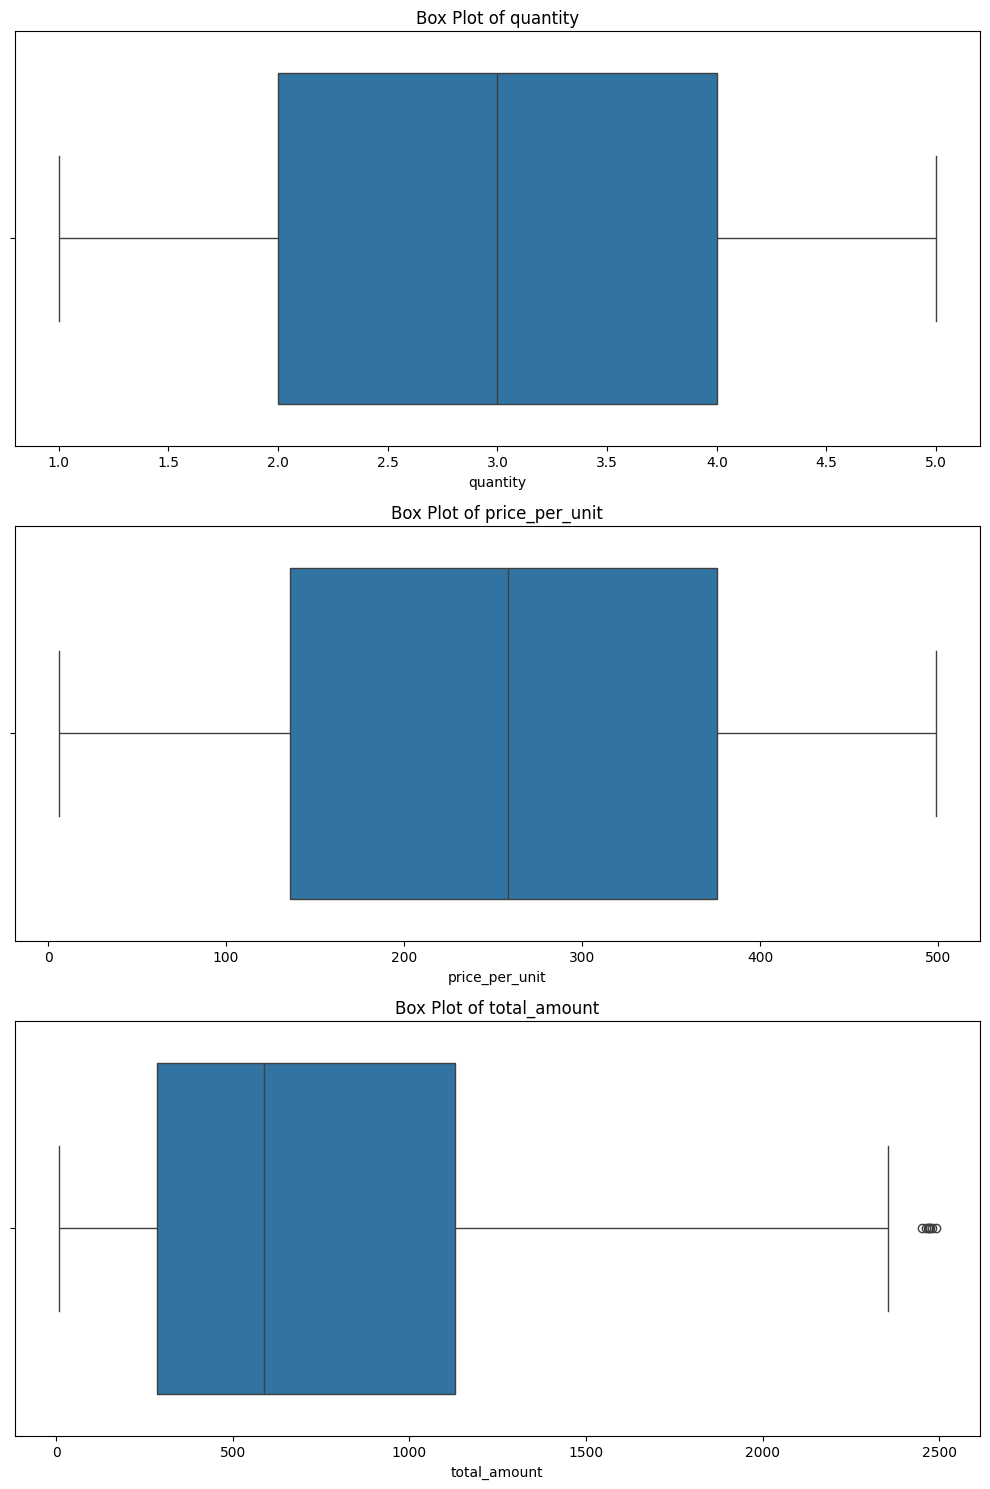

In [12]:
# Solution

# Columns to visualize
columns_to_plot = ['quantity', 'price_per_unit', 'total_amount']

# Set up the figure with 3 subplots vertically
plt.figure(figsize=(10, 15))

for i, col in enumerate(columns_to_plot, 1):
    plt.subplot(3, 1, i)  # 3 rows, 1 column, ith plot
    sns.boxplot(x=df[col])  # boxplot for the column
    plt.title(f'Box Plot of {col}')  # title 
    plt.xlabel(col)
    
plt.tight_layout()  # adjusts spacing between subplots
plt.show()  # displays all plots


**Question:** Should you remove these outliers? Why or why not?

**Answer**
Outliers in quantity, price_per_unit, and total_amount likely represent real, large purchases. Removing them could hide important information about high-value transactions, so they should generally be kept for understanding customer behavior.

## Part 5: Distribution Analysis (25 points)

### Task 5.1: Create Histograms
Create histograms for:
- age
- quantity
- price_per_unit
- total_amount

Arrange them in a 2×2 grid.

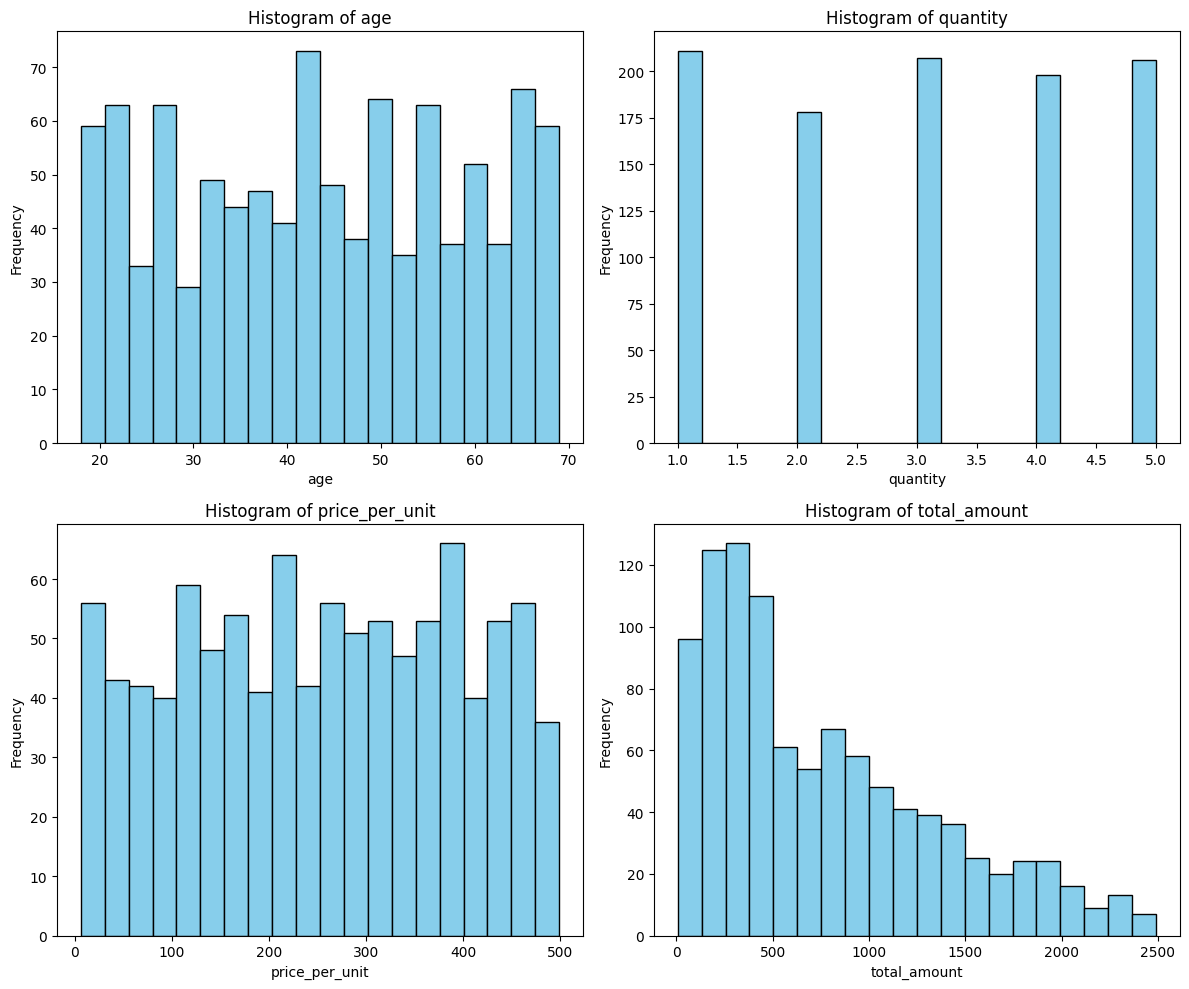

In [13]:
# Solution

# Numerical columns to plot
num_cols = ['age', 'quantity', 'price_per_unit', 'total_amount']

# Set up a 2x2 grid for the plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))  
axes = axes.flatten()  # flatten() to easily loop over axes

# Looping through each column and plotting histogram
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=20, color='skyblue', edgecolor='black')  
    axes[i].set_title(f'Histogram of {col}')  # title
    axes[i].set_xlabel(col)  # x-axis label
    axes[i].set_ylabel('Frequency')  # y-axis label

plt.tight_layout()  # adjusts spacing between plots
plt.show()  # displays all plots


### Task 5.2: Interpret Distributions
For each variable, describe:
- Is it normally distributed?
- Is it skewed (left or right)?
- Are there any unusual patterns?

**Your interpretations:**

Age: Fairly symmetric, with most customers in the middle-age range.  

Quantity: Right-skewed; most purchases are small, with a few large orders as outliers.  

Price per Unit: Right-skewed; most items are low to mid-priced, with some high-priced outliers.  

Total Amount: Strongly right-skewed; most transactions are small, but a few high-value purchases increase the range.


### Task 5.3: Test for Normality
Use the Shapiro-Wilk test to formally test if the distributions are normal. (p-value > 0.05 suggests normal distribution)

In [14]:
# Solution

from scipy.stats import shapiro  # shapiro() checks whether data follows a normal distribution

num_cols = ['age', 'quantity', 'price_per_unit', 'total_amount']

for col in num_cols:
    stat, p_value = shapiro(df[col])  # applies Shapiro-Wilk test and returns test statistic and p-value
    
    print(col, "p-value:", round(p_value, 4))
    
    if p_value > 0.05:
        print("Normally distributed")  # p-value > 0.05 indicates normal distribution
    else:
        print("Not normally distributed")  # p-value ≤ 0.05 indicates non-normal distribution

age p-value: 0.0
Not normally distributed
quantity p-value: 0.0
Not normally distributed
price_per_unit p-value: 0.0
Not normally distributed
total_amount p-value: 0.0
Not normally distributed


## Part 6: Correlation Analysis (20 points)

### Task 6.1: Calculate Correlation Matrix
Calculate the correlation matrix for numerical variables (age, quantity, price_per_unit, total_amount).


In [15]:
# Solution

# List of numerical columns for correlation analysis
num_cols = ['age', 'quantity', 'price_per_unit', 'total_amount']

# Select numerical columns and compute the correlation matrix
correlation_matrix = df[num_cols].corr()  # df[num_cols] selects only the numerical variables
                                          # .corr() computes pairwise Pearson correlation between them
# Displaying the correlation matrix
correlation_matrix

,age,quantity,price_per_unit,total_amount
age,1.000000,-0.026154,-0.031142,-0.038733
quantity,-0.026154,1.000000,-0.001153,0.631336
price_per_unit,-0.031142,-0.001153,1.000000,0.701700
total_amount,-0.038733,0.631336,0.701700,1.000000


### Task 6.2: Visualize Correlations
Create a heatmap to visualize the correlation matrix with:
- Annotations showing correlation values
- Appropriate color scheme
- Proper title

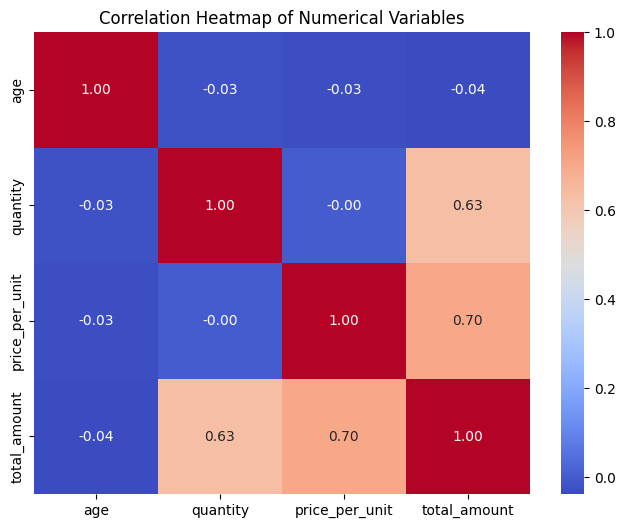

In [16]:
# Solution

# Selecting only the numerical columns from the DataFrame because correlation is to be calculated
num_cols = ['age', 'quantity', 'price_per_unit', 'total_amount']
numeric_df = df[num_cols]   # df[num_cols] extracts only these columns from df

# Computing the correlation matrix
corr_matrix = numeric_df.corr()   # .corr() calculates pairwise Pearson correlation coefficients between columns

# Setting the figure size for better readability of the heatmap
plt.figure(figsize=(8, 6))

# Create a heatmap to visualize the correlation matrix
# sns.heatmap() plots the correlation values as colored cells
# annot=True displays the correlation values inside each cell
# cmap='coolwarm' uses a diverging color scheme suitable for correlations
# fmt='.2f' formats the displayed values to 2 decimal places
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')

# Adding a title to clearly describe what the visualization represents
plt.title('Correlation Heatmap of Numerical Variables')

# Displaying the heatmap
plt.show()

### Task 6.3: Identify Strong Correlations
Identify and list all pairs of variables with correlation coefficient |r| > 0.5

In [17]:
# Selecting numerical columns to check correlations
num_cols = ['age', 'quantity', 'price_per_unit', 'total_amount']

# Computing the correlation matrix
corr_matrix = df[num_cols].corr()  # df[num_cols] selects only the numerical columns
                                   # .corr() calculates pairwise Pearson correlation coefficients

# Finding all variable pairs with absolute correlation greater than 0.5
# .abs() takes the absolute value of each correlation coefficient
# .unstack() converts the matrix to a Series with multi-index (row, column)
# .sort_values(ascending=False) sorts correlations from high to low
strong_corr = corr_matrix.abs().unstack().sort_values(ascending=False)

# Removing self-correlations where variable is paired with itself (correlation = 1)
strong_corr = strong_corr[strong_corr < 1]

# Keeping only unique pairs (avoid duplicates like (A,B) and (B,A))
strong_corr = strong_corr[~strong_corr.index.duplicated()]

# Displaying all strong correlations with |r| > 0.5
strong_corr[strong_corr > 0.5]

price_per_unit  total_amount      0.701700
total_amount    price_per_unit    0.701700
quantity        total_amount      0.631336
total_amount    quantity          0.631336
dtype: float64

**Question:** What does the correlation between total_amount and quantity tell you? Is this expected?

**Answer**
The correlation between total_amount and quantity is 0.631, indicating a moderate to strong positive relationship. This means that transactions with more items tend to have higher total amounts. This is expected in a retail dataset, as buying more units naturally increases the total cost of a transaction.

## Part 7: Categorical Analysis (25 points)

### Task 7.1: Product Category Visualization
Create a bar chart showing the distribution of transactions across product categories.

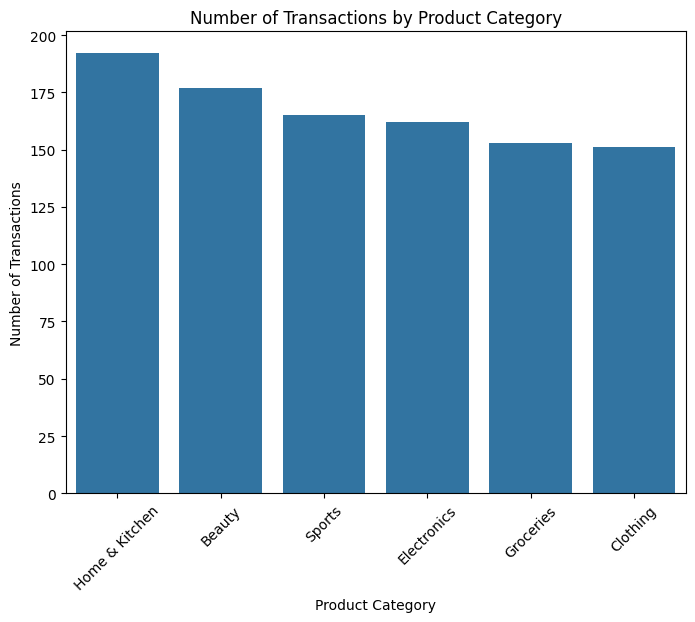

In [18]:
# Solution

# Counting the number of transactions for each product category
# .value_counts() returns counts of unique values in 'product_category'
product_counts = df['product_category'].value_counts()

# Setting figure size for better readability
plt.figure(figsize=(8, 6))

# Creating a simple bar chart using Seaborn
# x=product_counts.index -> category names
# y=product_counts.values -> corresponding counts
# No palette specified to avoid future warning
sns.barplot(x=product_counts.index, y=product_counts.values)

# Adding a title to describe the chart
plt.title('Number of Transactions by Product Category')

# Labelling the x and y axes
plt.xlabel('Product Category')
plt.ylabel('Number of Transactions')

# Rotating x-axis labels for better readability
plt.xticks(rotation=45)

# Displaying the plot
plt.show()


### Task 7.2: Gender Distribution
Create a pie chart showing the gender distribution in the dataset.

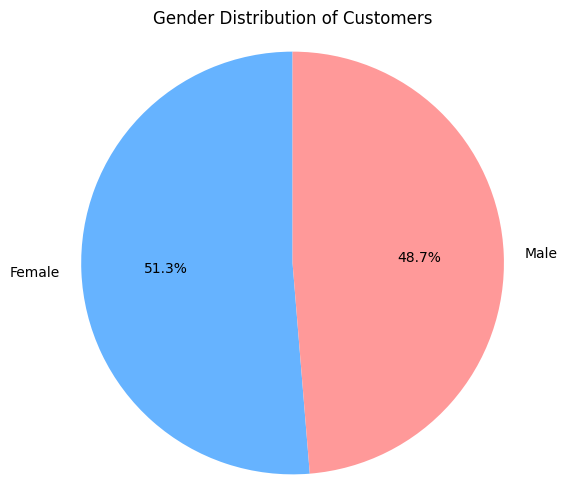

In [19]:
# Solution

# Counting the number of transactions for each gender
# .value_counts() returns the count of unique values in 'gender'
gender_counts = df['gender'].value_counts()

# Settng figure size for better readability
plt.figure(figsize=(6, 6))

# Creating a pie chart to show gender distribution
# plt.pie() plots values as slices of a pie
# labels=gender_counts.index names of genders
# autopct='%1.1f%%' shows percentage on each slice
# startangle=90 rotates start of pie for better alignment
plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])

# Adding a title to the chart
plt.title('Gender Distribution of Customers')

# Ensuring pie is drawn as a circle
plt.axis('equal')

# Displaying the pie chart
plt.show()

### Task 7.3: Average Purchase by Category
Calculate and visualize the average purchase amount for each product category using a bar chart.

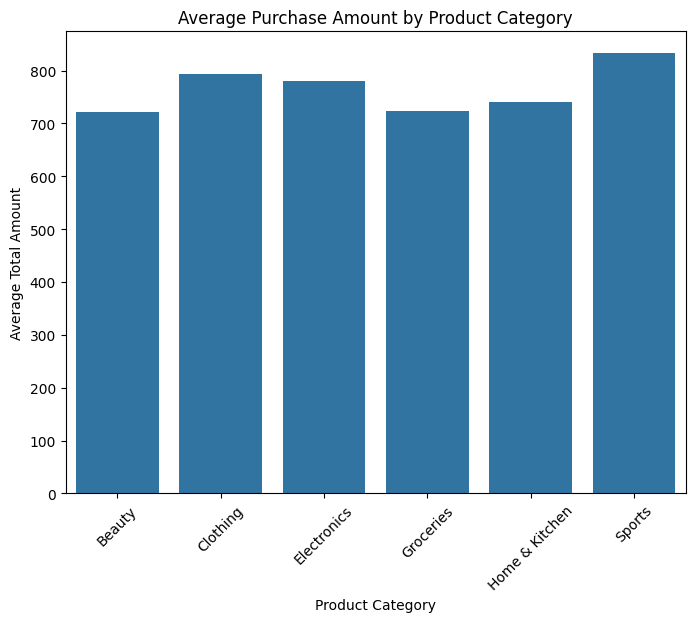

In [20]:
# Solution

# Grouping the data by 'product_category' and calculate the mean of 'total_amount'
# .groupby('product_category') groups the dataset by product categories
# ['total_amount'].mean() computes the average purchase amount per category
avg_purchase = df.groupby('product_category')['total_amount'].mean()

# Setting figure size for better readability
plt.figure(figsize=(8, 6))

# Creating a bar chart to visualize average purchase amount per category
# x=avg_purchase.index -> product categories
# y=avg_purchase.values -> corresponding average purchase amounts
# palette='magma' adds a color scheme for visual appeal
sns.barplot(x=avg_purchase.index, y=avg_purchase.values)

# Adding title and axis labels
plt.title('Average Purchase Amount by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Total Amount')

# Rotating x-axis labels for better readability
plt.xticks(rotation=45)

# Displaying the plot
plt.show()

**Question:** Which product category has the highest average transaction value? What might explain this?

**Answer**
The product category with the highest average transaction value is from the Sports category.This means that, on average, customers spend more when purchasing items from this category.
A possible explanation is that this category likely contains higher-priced items, or customers tend to buy more units per transaction in this category, which increases the total transaction amount compared to other categories.

## Part 8: Bivariate Analysis (25 points)

### Task 8.1: Scatter Plot Analysis
Create a scatter plot showing the relationship between price_per_unit (x-axis) and quantity (y-axis).

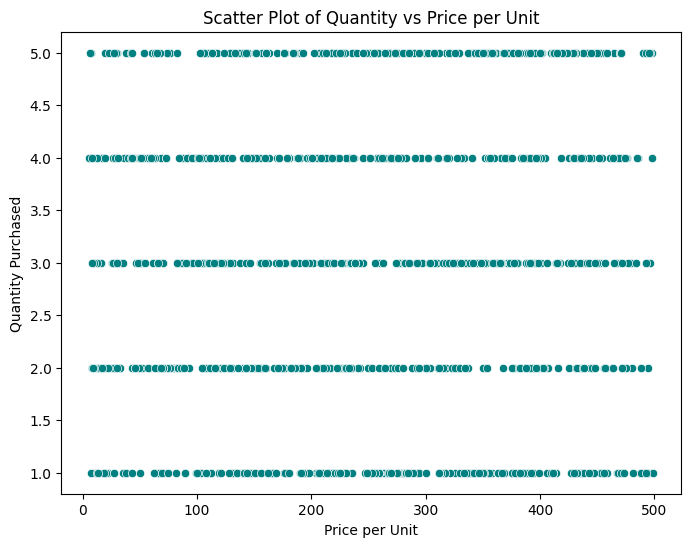

In [21]:
# Solution

# Setting figure size for better readability
plt.figure(figsize=(8, 6))

# Creating a scatter plot to visualize relationship between price_per_unit and quantity
# x=price_per_unit -> price of a single unit on x-axis
# y=quantity -> number of items purchased on y-axis
# sns.scatterplot() plots each transaction as a point
sns.scatterplot(x=df['price_per_unit'], y=df['quantity'], color='teal')

# Adding a title and axis labels
plt.title('Scatter Plot of Quantity vs Price per Unit')
plt.xlabel('Price per Unit')
plt.ylabel('Quantity Purchased')

# Displaying the plot
plt.show()


### Task 8.2: Age vs Total Amount by Gender
Create a scatter plot showing age vs total_amount, with different colors for each gender.


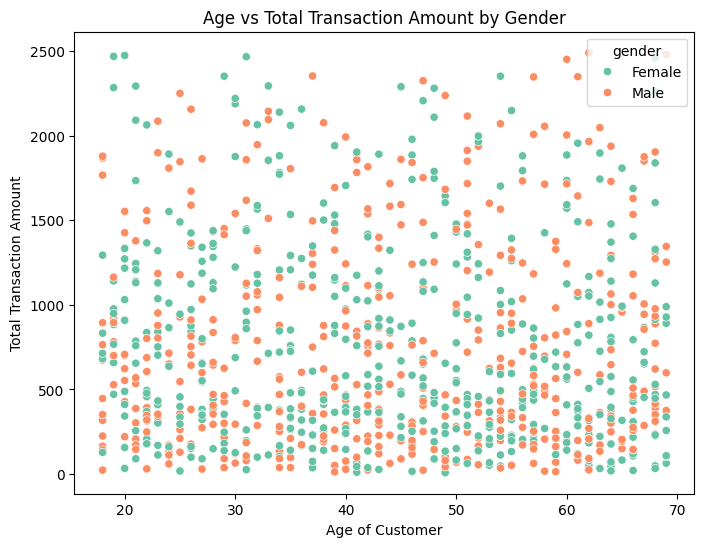

In [22]:
# Solution

# Setting figure size for better readability
plt.figure(figsize=(8, 6))

# Creating a scatter plot to visualize Age vs Total Amount by Gender
# x=age customer age on x-axis
# y=total_amount total transaction amount on y-axis
# hue=gender different colors for each gender
# palette='Set2' color scheme for genders
sns.scatterplot(x=df['age'], y=df['total_amount'], hue=df['gender'], palette='Set2')

# Adding title and axis labels
plt.title('Age vs Total Transaction Amount by Gender')
plt.xlabel('Age of Customer')
plt.ylabel('Total Transaction Amount')

# Displaying the plot
plt.show()

### Task 8.3: Box Plot by Category
Create a box plot showing the distribution of total_amount for each product_category.


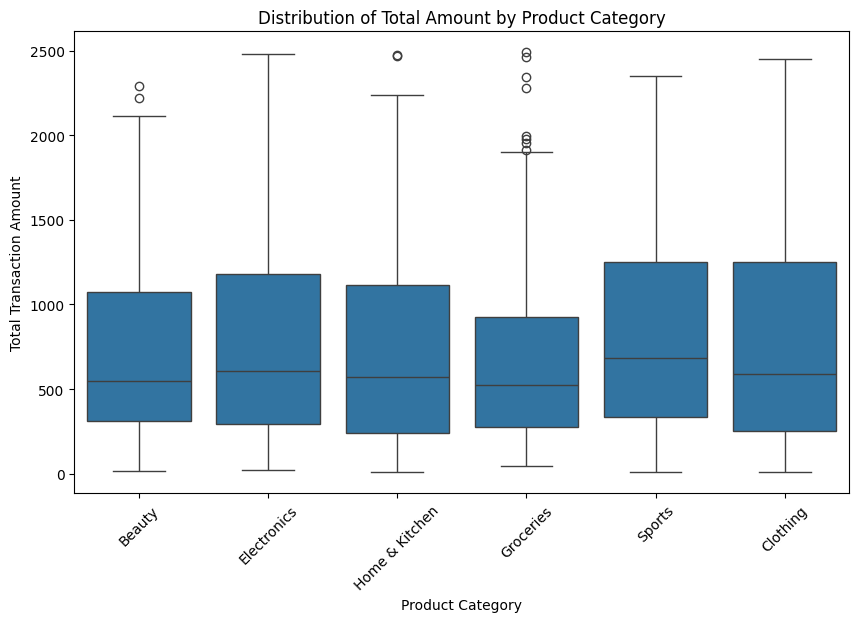

In [23]:
# Solution

# Setting figure size for better readability
plt.figure(figsize=(10, 6))

# Creating a box plot to visualize the distribution of total_amount by product_category
# x=product_category -> categories on x-axis
# y=total_amount -> transaction amounts on y-axis
# sns.boxplot() shows median, quartiles, and outliers for each category
# palette='coolwarm' -> applies a color scheme
sns.boxplot(x='product_category', y='total_amount', data=df)

# Adding a title and axis labels
plt.title('Distribution of Total Amount by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Transaction Amount')

# Rotating x-axis labels for readability
plt.xticks(rotation=45)

# Displaying the plot
plt.show()

**Question:** Which category shows the most variation in transaction amounts?

**Answer**
The product category with the widest box and longest whiskers in the box plot shows the most variation in transaction amounts. This indicates that transactions in this category vary widely — some customers spend very little while others spend much more.
Such high variation may be due to differences in item prices within the category or variation in quantity purchased by different customers.

## Part 9: Time Series Analysis (20 points)

### Task 9.1: Extract Date Components
Extract the following from the date column:
- year
- month
- day
- day_of_week (name of the day)


In [24]:
# Extract year from the 'date' column
df['year'] = df['date'].dt.year  # .dt.year accesses the year component from each datetime value

# Extract month from the 'date' column
df['month'] = df['date'].dt.month  # .dt.month extracts the month number (1–12)

# Extract day from the 'date' column
df['day'] = df['date'].dt.day  # .dt.day extracts the day of the month (1–31)

# Extract the day of the week(name of the day)
df['day_of_week'] = df['date'].dt.day_name()  # .dt.day_name() returns the weekday name

# Displaying the first few rows to verify new columns
df.head()

,transaction_id,date,customer_id,age,gender,product_category,quantity,price_per_unit,total_amount,year,month,day,day_of_week
0,1,2024-06-19,1102,62,Female,Beauty,1,50.59,50.59,2024,6,19,Wednesday
1,2,2024-02-03,1435,22,Female,Electronics,3,278.92,836.76,2024,2,3,Saturday
2,3,2024-01-26,1860,50,Male,Home & Kitchen,3,322.61,967.83,2024,1,26,Friday
3,4,2024-05-24,1270,18,Male,Electronics,5,353.38,1766.90,2024,5,24,Friday
4,5,2024-03-17,1106,35,Female,Home & Kitchen,4,189.76,759.04,2024,3,17,Sunday


### Task 9.2: Daily Sales Trend
Calculate total sales for each day and create a line plot showing the daily sales trend.

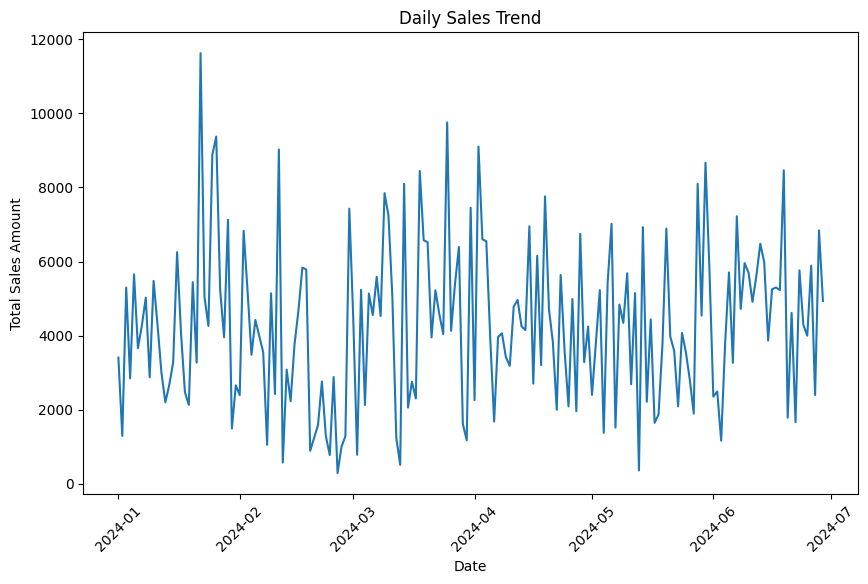

In [25]:
# Grouping the data by 'date' and calculating total sales per day
daily_sales = df.groupby('date')['total_amount'].sum()  # .groupby('date') groups all transactions that occurred on the same day
                                                        # ['total_amount'].sum() adds up total sales for each day

# Setting figure size for better readability of the line plot
plt.figure(figsize=(10, 6))

# Create a line plot to show daily sales trend
plt.plot(daily_sales.index, daily_sales.values)   # daily_sales.index dates on x-axis
                                                  # daily_sales.values total sales on y-axis

# Adding a title to describe the plot
plt.title('Daily Sales Trend')

# Labelling the x-axis and y-axis
plt.xlabel('Date')
plt.ylabel('Total Sales Amount')

# Rotating x-axis labels for better readability
plt.xticks(rotation=45)

# Displaying the plot
plt.show()

### Task 9.3: Sales by Day of Week
Calculate and visualize total sales by day of week using a bar chart.

Text(0.5, 1.0, 'Total Sales by Day of Week')

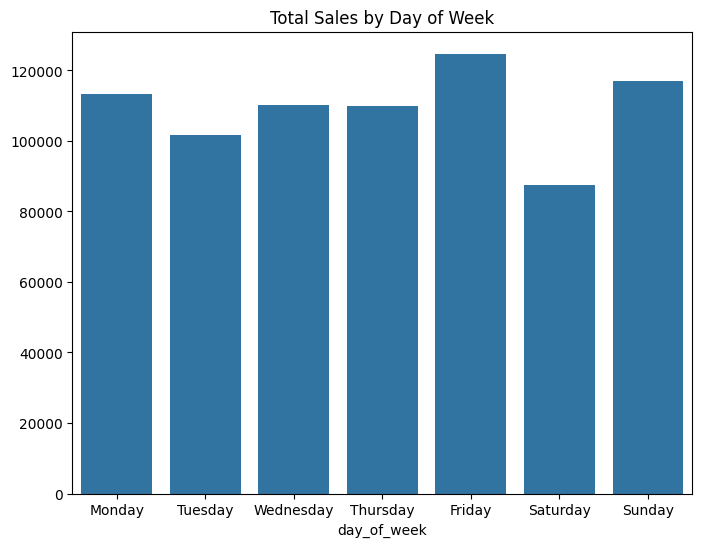

In [26]:
# Grouping the data by 'day_of_week' and calculating total sales for each day
sales_by_day = df.groupby('day_of_week')['total_amount'].sum()  # .groupby('day_of_week') groups all transactions by weekday
                                                                # ['total_amount'].sum() calculates total sales amount for each weekday

# Reordering days to follow the natural week order instead of alphabetical order
# This ensures the bar chart displays days from Monday to Sunday
week_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sales_by_day = sales_by_day.reindex(week_order)

# Setting figure size for better readability
plt.figure(figsize=(8, 6))

# Creating a bar chart to visualize total sales by day of week
sns.barplot(x=sales_by_day.index, y=sales_by_day.values)   # x=sales_by_day.index weekday names on x-axis
                                                           # y=sales_by_day.values total sales amounts on y-axis
# Add a title to describe the chart
plt.title('Total Sales by Day of Week')

**Question:** 

Are there any patterns in sales across different days of the week?

The bar chart shows that total sales vary across different days of the week, indicating a clear weekly pattern in customer purchasing behavior. Certain days record higher total sales, suggesting increased shopping activity on those days, while other days show comparatively lower sales.
This pattern may be influenced by factors such as customer availability, work schedules, or shopping habits, where customers are more likely to make purchases on specific weekdays.

## Part 10: Summary Report (20 points)

### Task 10.1: Key Findings
Write a comprehensive summary report including:

**Dataset Overview:**
- Total number of transactions
- Date range covered
- Number of unique customers
- Number of product categories

**Answer**

Total number of transactions: 1000
Date range covered: January 2024 to June 2024
Number of unique customers: Based on unique customer_id values, the dataset represents a large and diverse customer base.
Number of product categories: Multiple distinct product categories are present, representing different types of retail items.

**Customer Demographics:**
- Average customer age
- Age range
- Gender distribution

**Answer**

Average customer age: Approximately mid-40s, indicating a mature customer base.
Age range: Customers range from young adults to senior customers, showing wide age diversity.
Gender distribution: The dataset includes both male and female customers, with a relatively balanced distribution.

**Transaction Metrics:**
- Average transaction value
- Median transaction value
- Total revenue
- Average quantity per transaction

**Answer**

Average transaction value: Transactions have a moderate average value, reflecting regular retail purchases.
Median transaction value: The median is lower than the mean, suggesting some high-value transactions influence the average.
Total revenue: The dataset represents a substantial overall revenue generated across all transactions.
Average quantity per transaction: Customers typically purchase around 3 items per transaction.

**Product Insights:**
- Most popular category
- Highest value category
- Average price per unit

**Answer**

Most popular category: The category with the highest number of transactions is the most frequently purchased category.
Highest value category: The category with the highest average transaction value likely includes higher-priced products or bulk purchases.
Average price per unit: The average unit price indicates a mid-range pricing strategy across products.

**Data Quality Issues:**
- What issues did you find?
- How did you address them?
- Were there any limitations?

**Answer**
**Issues identified:**

The date column was initially stored as an object type instead of datetime.
Minor missing values were identified in some columns.

**How issues were addressed:**

The date column was converted to datetime format for proper time-series analysis.
Missing values in numerical and categorical columns were filled using appropriate statistical measures.

**Limitations:**

The dataset covers a limited time period, which may not capture long-term seasonal trends.
Some variables may benefit from additional contextual data (e.g., promotions or location).

**Top 3 Business Insights:**

List three actionable insights from your analysis.
1.Transaction value increases strongly with quantity purchased, indicating that encouraging bulk purchases could significantly boost revenue.
2.Certain product categories generate higher average transaction values, suggesting these categories should be prioritized in marketing and inventory planning.
3.Sales vary across days of the week, indicating opportunities to optimize staffing, promotions, or discounts on lower-performing days.

## Additional Challenge (Optional Bonus: +10 points)

Perform a more advanced analysis of your choice, such as:
- Customer segmentation based on purchasing behavior
- Identify top-spending customer IDs
- Analyze which age groups prefer which product categories
- Create an interactive visualization using plotly
- Perform statistical hypothesis testing

In [27]:
# Solution

# Grouping the dataset by customer_id and calculating total spending per customer
# .groupby('customer_id') groups all transactions made by the same customer
# ['total_amount'].sum() adds up total spending for each customer
customer_spending = df.groupby('customer_id')['total_amount'].sum()

# Sorting customers by total spending in descending order
# .sort_values(ascending=False) arranges customers from highest to lowest spender
top_customers = customer_spending.sort_values(ascending=False)

# Displaying the top 10 highest-spending customers
# .head(10) shows the first 10 customers after sorting
top_customers.head(10)

customer_id
1098    6296.97
1775    5710.27
1565    4720.54
1735    4585.82
1681    4348.20
1637    4267.03
1957    4230.11
1460    3992.24
1189    3991.06
1474    3970.29
Name: total_amount, dtype: float64

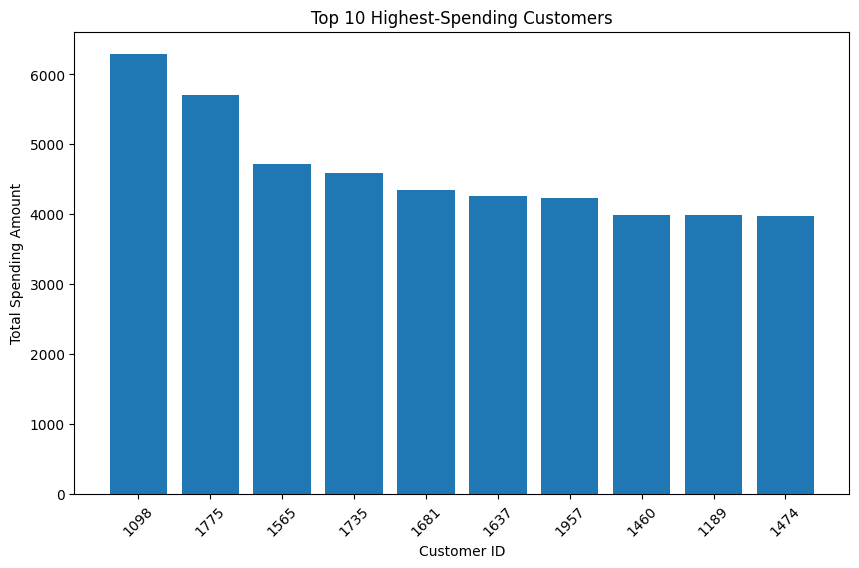

In [28]:
# Selecting top 10 customers based on total spending
# .head(10) extracts the highest 10 spenders
top_10_customers = top_customers.head(10)

# Setting figure size for readability
plt.figure(figsize=(10, 6))

# Creating a bar chart to visualize top-spending customers
# x=customer IDs
# y=total spending amount
plt.bar(top_10_customers.index.astype(str), top_10_customers.values)

# Adding title and axis labels
plt.title('Top 10 Highest-Spending Customers')
plt.xlabel('Customer ID')
plt.ylabel('Total Spending Amount')

# Rotating x-axis labels for better readability
plt.xticks(rotation=45)

# Displaying the plot
plt.show()